# IMPORT LIBRARIES

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ast import literal_eval
import numpy as np


# LOAD CSV AND EDA

In [16]:
pd.set_option("display.max_colwidth", None)  # Show full content in columns
pd.set_option("display.max_rows", None)

Dataset provided description:

Represents the domestic daily gross income of movies at the box office,
starting from their release date.
• ~1k time series, each associated with the movie's genre and rating (avg and category);

In [56]:
# Load the IMDb time series dataset
file_path = "dataset/imdb_ts.csv"
df = pd.read_csv(file_path)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1134 entries, 0 to 1133
Columns: 104 entries, id to rating_category
dtypes: float64(101), object(3)
memory usage: 921.5+ KB


In [11]:
df.head()

,id,0,1,2,3,4,5,6,7,8,...,93,94,95,96,97,98,99,rating,genre,rating_category
0,tt0062622,57057.0,65469.0,71642.0,73025.0,74060.0,49472.0,30258.0,28036.0,25824.0,...,10709.0,11042.0,11388.0,11847.0,12404.0,13679.0,15056.0,8.3,"['Adventure', 'Sci-Fi']",High
1,tt0064816,1923.0,2422.0,2853.0,2947.0,3054.0,2844.0,2617.0,1998.0,1277.0,...,637.0,734.0,857.0,785.0,724.0,713.0,699.0,7.1,"['Crime', 'Drama', 'Romance']",High
2,tt0088178,332925.0,302503.0,267264.0,261879.0,256608.0,196530.0,112728.0,117384.0,123024.0,...,6784.0,7253.0,7776.0,9632.0,11212.0,9010.0,6431.0,8.7,"['Documentary', 'Music']",High
3,tt0145487,682857.0,407032.0,78058.0,81732.0,86772.0,83724.0,79940.0,39656.0,6974.0,...,21094.0,10995.0,1586.0,1421.0,1177.0,970.0,802.0,7.4,"['Action', 'Adventure', 'Sci-Fi']",High
4,tt0359950,7813372.0,6274563.0,4781588.0,4655046.0,4535301.0,4650574.0,4758452.0,4069428.0,3471755.0,...,88635.0,68347.0,45367.0,28915.0,15494.0,16155.0,16853.0,7.3,"['Adventure', 'Comedy', 'Drama']",High


In [ ]:
df.shape


(1134, 104)

In [17]:
missing_values = df.isnull().sum()
missing_values

id                 0
0                  0
1                  0
2                  0
3                  0
4                  0
5                  0
6                  0
7                  0
8                  0
9                  0
10                 0
11                 0
12                 0
13                 0
14                 0
15                 0
16                 0
17                 0
18                 0
19                 0
20                 0
21                 0
22                 0
23                 0
24                 0
25                 0
26                 0
27                 0
28                 0
29                 0
30                 0
31                 0
32                 0
33                 0
34                 0
35                 0
36                 0
37                 0
38                 0
39                 0
40                 0
41                 0
42                 0
43                 0
44                 0
45                 0
46           

In [20]:
df.describe()["rating"]


count    1134.000000
mean        6.584921
std         0.900217
min         2.800000
25%         6.100000
50%         6.600000
75%         7.300000
max         8.700000
Name: rating, dtype: float64

In [22]:
time_series_cols = [str(i) for i in range(100)]
time_series_cols

['0',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 '10',
 '11',
 '12',
 '13',
 '14',
 '15',
 '16',
 '17',
 '18',
 '19',
 '20',
 '21',
 '22',
 '23',
 '24',
 '25',
 '26',
 '27',
 '28',
 '29',
 '30',
 '31',
 '32',
 '33',
 '34',
 '35',
 '36',
 '37',
 '38',
 '39',
 '40',
 '41',
 '42',
 '43',
 '44',
 '45',
 '46',
 '47',
 '48',
 '49',
 '50',
 '51',
 '52',
 '53',
 '54',
 '55',
 '56',
 '57',
 '58',
 '59',
 '60',
 '61',
 '62',
 '63',
 '64',
 '65',
 '66',
 '67',
 '68',
 '69',
 '70',
 '71',
 '72',
 '73',
 '74',
 '75',
 '76',
 '77',
 '78',
 '79',
 '80',
 '81',
 '82',
 '83',
 '84',
 '85',
 '86',
 '87',
 '88',
 '89',
 '90',
 '91',
 '92',
 '93',
 '94',
 '95',
 '96',
 '97',
 '98',
 '99']

In [24]:
mean_time_series = df[time_series_cols].mean()
mean_time_series

0     9.075217e+06
1     8.521398e+06
2     7.954433e+06
3     7.080579e+06
4     6.200350e+06
5     4.567772e+06
6     2.943717e+06
7     2.932913e+06
8     2.929824e+06
9     2.503033e+06
10    2.078626e+06
11    2.000192e+06
12    1.914377e+06
13    2.652985e+06
14    3.389386e+06
15    3.964869e+06
16    4.537992e+06
17    3.983342e+06
18    3.421181e+06
19    2.578696e+06
20    1.737905e+06
21    1.730916e+06
22    1.729025e+06
23    1.495507e+06
24    1.257706e+06
25    1.205054e+06
26    1.153670e+06
27    1.540577e+06
28    1.928203e+06
29    2.299746e+06
30    2.670163e+06
31    2.330152e+06
32    1.990498e+06
33    1.519953e+06
34    1.039019e+06
35    1.032399e+06
36    1.025991e+06
37    8.724541e+05
38    7.163106e+05
39    6.841676e+05
40    6.688020e+05
41    6.537530e+05
42    9.031358e+05
43    1.155366e+06
44    1.424853e+06
45    1.688625e+06
46    1.474880e+06
47    1.255024e+06
48    9.567281e+05
49    6.596365e+05
50    6.543843e+05
51    6.486978e+05
52    5.5164

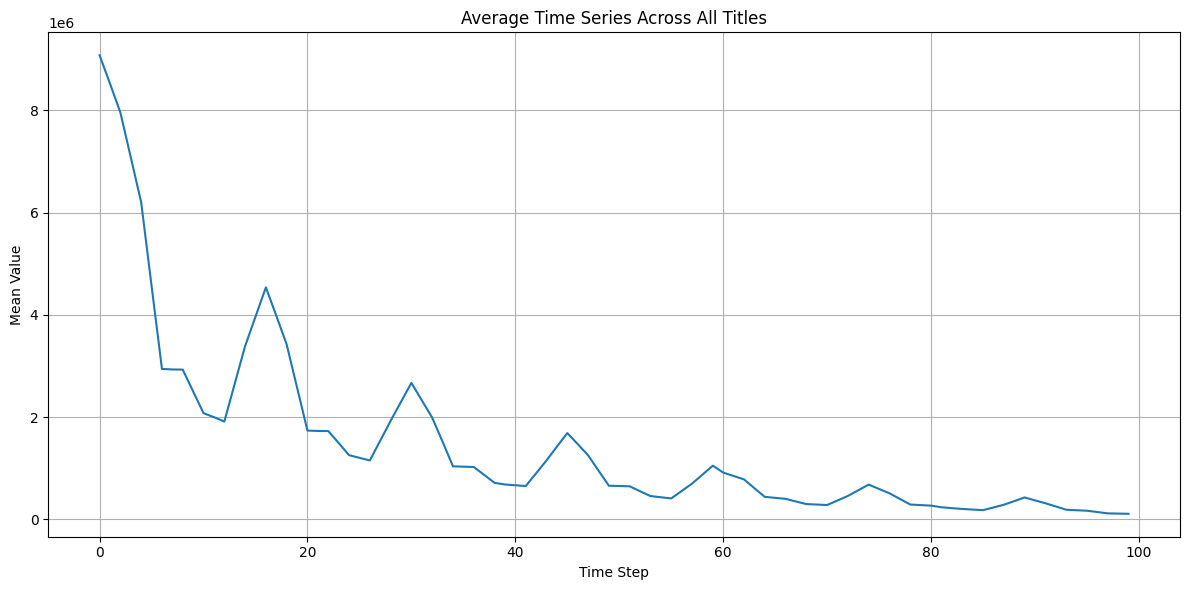

In [25]:
# Plot the average time series
plt.figure(figsize=(12, 6))
plt.plot(mean_time_series.index.astype(int), mean_time_series.values)
plt.title("Average Time Series Across All Titles")
plt.xlabel("Time Step")
plt.ylabel("Mean Value")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Create separate dataframes by rating category for time series comparison
rating_categories = df["rating_category"].unique()
category_time_series = {
    cat: df[df["rating_category"] == cat][time_series_cols].mean()
    for cat in rating_categories
}


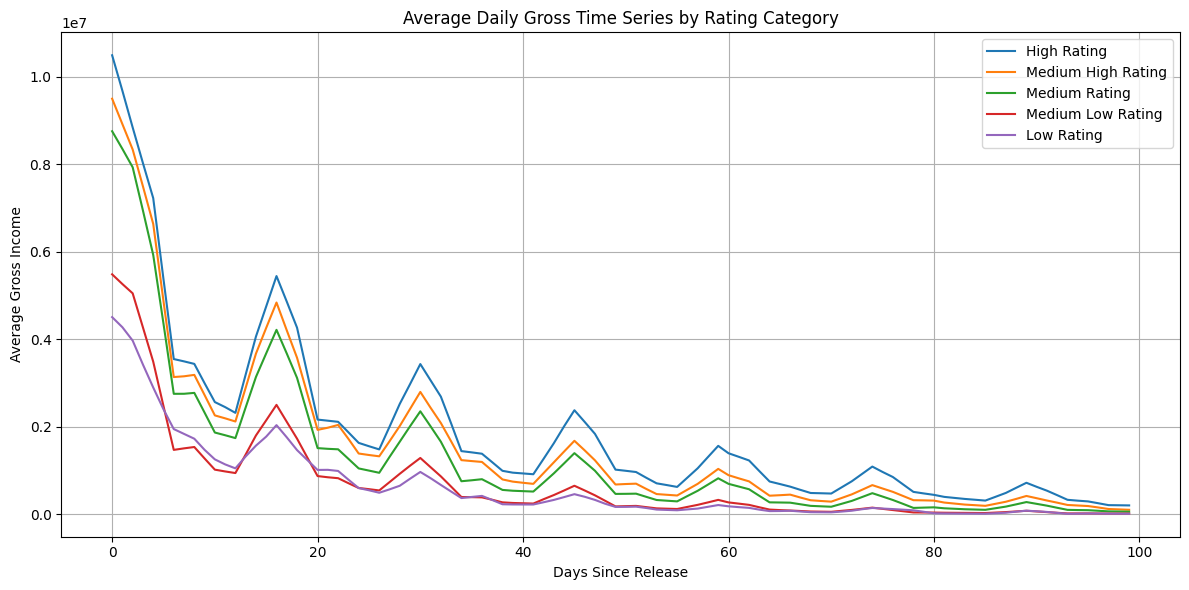

In [28]:
# Plot mean time series for each rating category
plt.figure(figsize=(12, 6))
for cat, series in category_time_series.items():
    plt.plot(series.index.astype(int), series.values, label=f"{cat} Rating")

plt.title("Average Daily Gross Time Series by Rating Category")
plt.xlabel("Days Since Release")
plt.ylabel("Average Gross Income")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

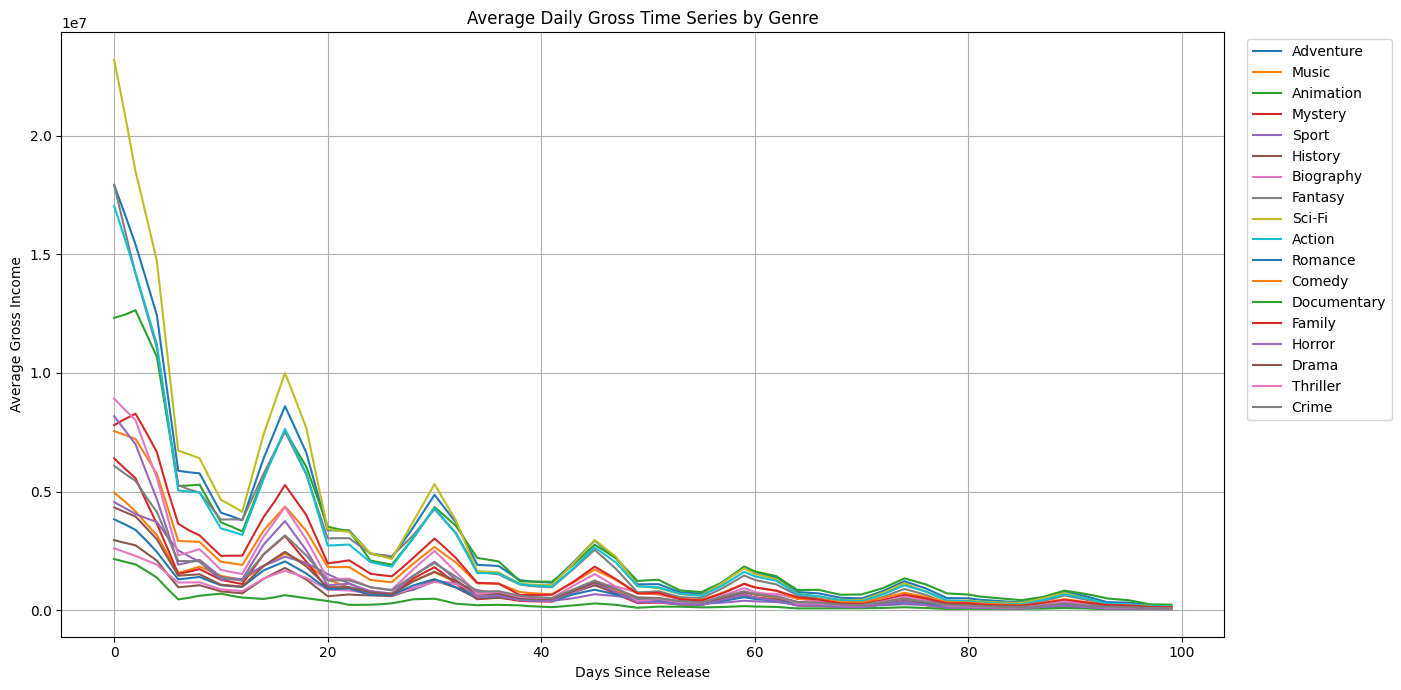

In [ ]:
# Convert genre string representations to lists
df["genre_list"] = df["genre"].apply(literal_eval)

# Flatten genre list to get all unique genres
all_genres = set(genre for sublist in df["genre_list"] for genre in sublist)

# Calculate mean time series per genre (for top few genres only to keep plot readable)
genre_time_series = {}
for genre in all_genres:
    genre_df = df[df["genre_list"].apply(lambda x: genre in x)]
    if (
        len(genre_df) > 20
    ):  # filter to only include genres with reasonable number of movies
        genre_time_series[genre] = genre_df[time_series_cols].mean()

# Plot average time series for selected genres
plt.figure(figsize=(14, 7))
for genre, series in genre_time_series.items():
    plt.plot(series.index.astype(int), series.values, label=genre)

plt.title("Average Daily Gross Time Series by Genre")
plt.xlabel("Days Since Release")
plt.ylabel("Average Gross Income")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Select fixed time stamps for ranking (e.g., day 0, 3, 7, 14, 30)
selected_days = ["0", "3", "7", "14", "30"]

# Create a ranking table
ranking_table = df[["id", "genre", "rating_category"] + selected_days].copy()

# Rank each movie based on gross income at each selected day (higher income = better rank)
for day in selected_days:
    ranking_table[f"rank_day_{day}"] = ranking_table[day].rank(ascending=False)

# Sort by day 0 rank to highlight strongest openers
ranking_table_sorted = ranking_table.sort_values(by="rank_day_0").reset_index(drop=True)


In [33]:
ranking_table_sorted.head(20)

,id,genre,rating_category,0,3,7,14,30,rank_day_0,rank_day_3,rank_day_7,rank_day_14,rank_day_30
0,tt4154796,"['Action', 'Adventure', 'Sci-Fi']",High,157461641.0,99058175.0,35160416.0,40736774.0,27542359.0,1.0,1.0,3.0,2.0,3.0
1,tt10872600,"['Action', 'Adventure', 'Fantasy']",High,121964712.0,68611283.0,34240709.0,19655506.0,23112936.0,2.0,3.0,4.0,23.0,5.0
2,tt2488496,"['Action', 'Adventure', 'Sci-Fi']",High,119119282.0,64701811.0,38889903.0,49325663.0,34368250.0,3.0,4.0,2.0,1.0,1.0
3,tt4154756,"['Action', 'Adventure', 'Sci-Fi']",High,106334939.0,74564309.0,24031431.0,31453749.0,26938937.0,4.0,2.0,16.0,5.0,4.0
4,tt2527336,"['Action', 'Adventure', 'Fantasy']",Medium High,104684491.0,58051463.0,20870167.0,24763084.0,19924241.0,5.0,7.0,18.0,14.0,10.0
5,tt6263850,"['Action', 'Adventure', 'Comedy']",High,96189710.0,56992001.0,24859887.0,28001874.0,21944866.0,6.0,9.0,13.0,10.0,8.0
6,tt9419884,"['Action', 'Adventure', 'Fantasy']",Medium High,90720784.0,48346676.0,13060151.0,17133926.0,13801107.0,7.0,15.0,53.0,34.0,34.0
7,tt2527338,"['Action', 'Adventure', 'Fantasy']",Medium,89615288.0,43369880.0,24408509.0,26069973.0,14319903.0,8.0,22.0,14.0,12.0,31.0
8,tt2395427,"['Action', 'Adventure', 'Sci-Fi']",High,84424532.0,53437472.0,13178538.0,21232362.0,17204358.0,9.0,12.0,52.0,22.0,17.0
9,tt9114286,"['Action', 'Adventure', 'Drama']",Medium High,84285721.0,48596323.0,11871870.0,17999138.0,17599193.0,10.0,14.0,58.0,32.0,16.0


# ANOMALIES

In [41]:
from sktime.transformations.series.func_transform import FunctionTransformer
from sktime.transformations.series.impute import Imputer


In [ ]:
def iqr_outliers(x, k=1.5):
    q1 = np.quantile(x, 0.25)
    q3 = np.quantile(x, 0.75)
    iqr = q3 - q1
    return np.array([(v < q1 - k * iqr or v > q3 + k * iqr) for v in x]).astype(int)


def iqr_outliers_prediction(x, k=1.5, starting_win=14):
    initial_labels = list(iqr_outliers(x[:starting_win], k))
    for i in range(starting_win, len(x)):
        initial_labels.append(iqr_outliers(np.array(x)[:i], k)[-1])
    return np.array(initial_labels)


In [ ]:
ts_data = df.loc[
    :, "0":"99"
]  # se le colonne dei giorni sono stringhe '0', '1', ..., '99'

In [ ]:
all_imputed = []

for i, row in ts_data.iterrows():
    x = row.values.astype(float)

    labels = iqr_outliers_prediction(x, k=1, starting_win=12)

    x[labels.astype(bool)] = np.nan

    imputer = Imputer(method="nearest")
    x_imputed = imputer.fit_transform(x).reshape(-1)

    all_imputed.append(x_imputed)


In [61]:
df_imputed = pd.DataFrame(all_imputed, columns=ts_data.columns)

In [ ]:
# Boolean DataFrame: True if the value changed
diff_mask = ts_data.astype(float) != df_imputed

# Count how many values changed per row (per series)
n_changed = diff_mask.sum(axis=1)

# Add to original dataframe for reference
df["n_changed"] = n_changed

# Filter the modified series
modified_series = df[df["n_changed"] > 0]

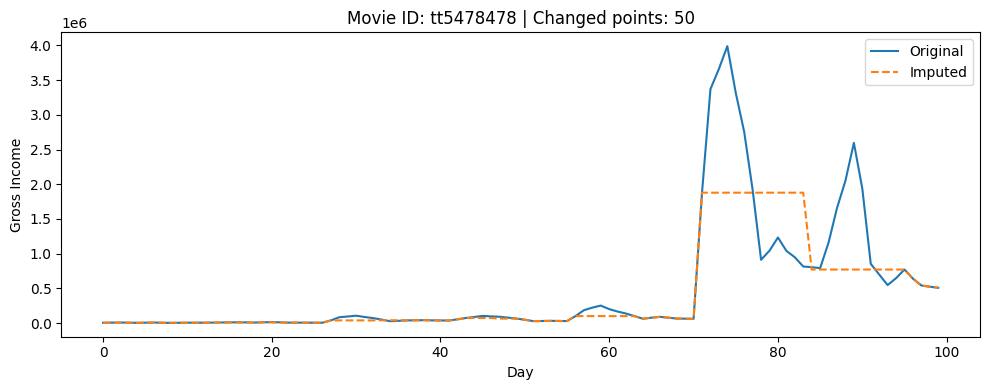

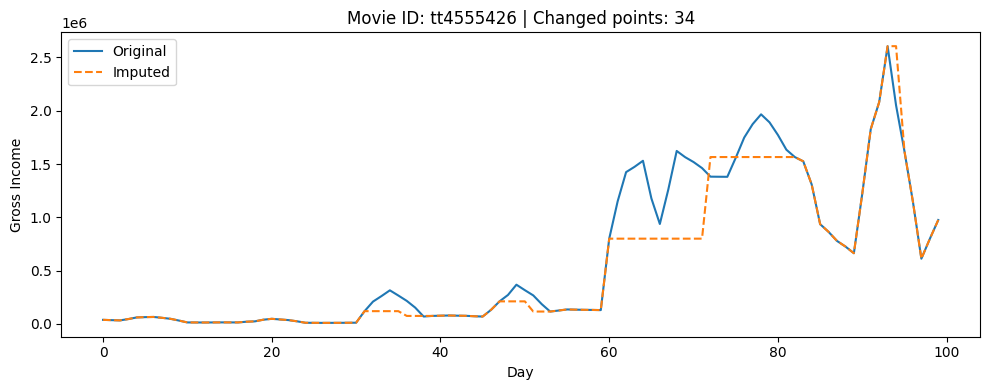

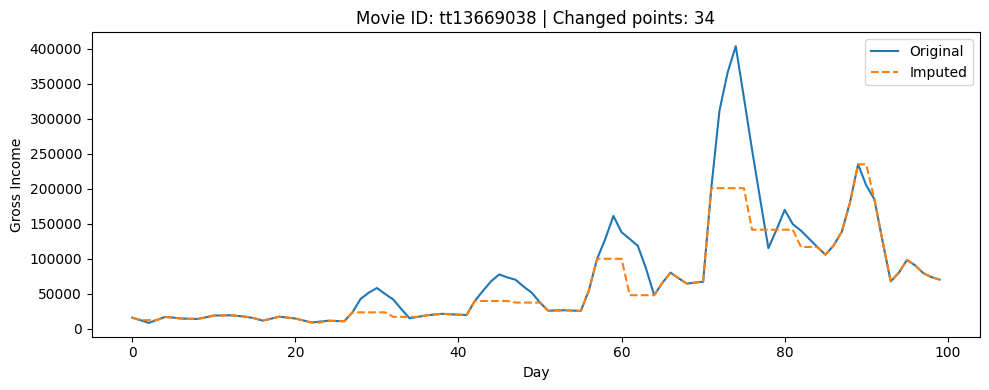

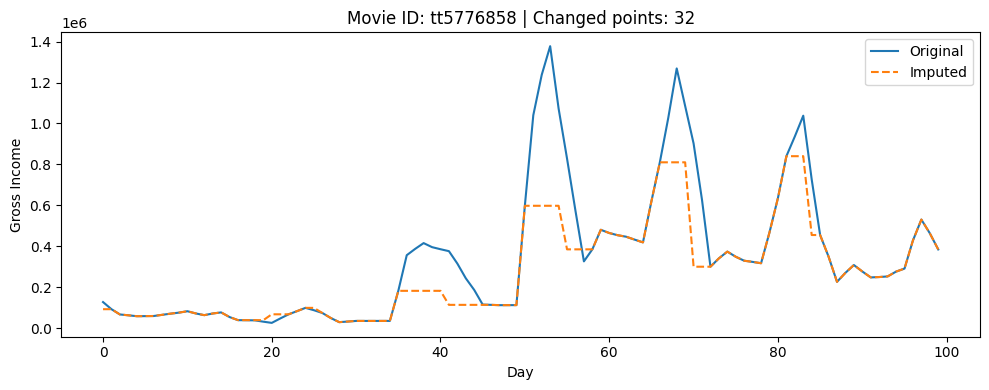

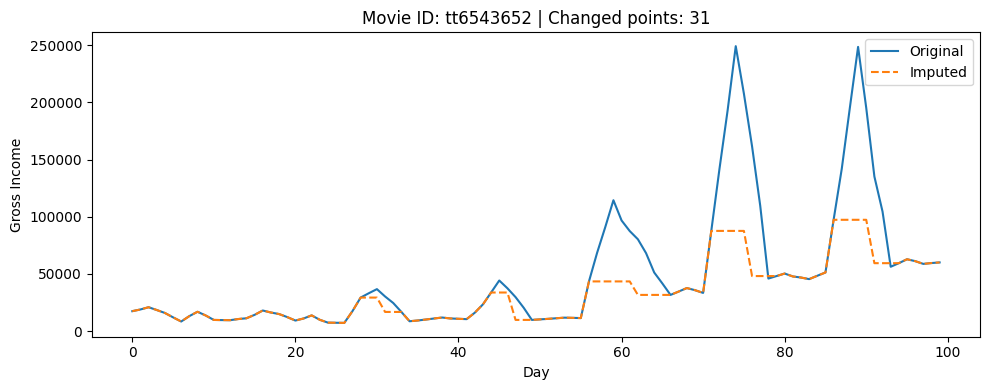

In [ ]:
diff_mask = ts_data.astype(float) != df_imputed
n_changed = diff_mask.sum(axis=1)
df["n_changed"] = n_changed

top5_indices = df.sort_values("n_changed", ascending=False).head(5).index

for i in top5_indices:
    plt.figure(figsize=(10, 4))
    plt.plot(ts_data.iloc[i].values, label="Original")
    plt.plot(df_imputed.iloc[i].values, label="Imputed", linestyle="--")
    plt.title(f"Movie ID: {df.loc[i, 'id']} | Changed points: {df.loc[i, 'n_changed']}")
    plt.xlabel("Day")
    plt.ylabel("Gross Income")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [73]:
df_imputed.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,57057.0,65469.0,71642.0,73025.0,74060.0,49472.0,30258.0,28036.0,25824.0,32571.0,...,13925.0,14370.0,12577.0,10709.0,11042.0,11388.0,11847.0,12404.0,13679.0,15056.0
1,1923.0,2422.0,2853.0,2947.0,3054.0,2844.0,2617.0,1998.0,1277.0,1449.0,...,1995.0,1972.0,1251.0,637.0,734.0,857.0,785.0,724.0,713.0,699.0
2,332925.0,302503.0,267264.0,261879.0,256608.0,196530.0,112728.0,117384.0,123024.0,119608.0,...,16273.0,14396.0,10518.0,6784.0,7253.0,7776.0,9632.0,11212.0,9010.0,6431.0
3,78058.0,78058.0,78058.0,81732.0,86772.0,83724.0,79940.0,39656.0,6974.0,7697.0,...,28490.0,24336.0,22421.0,21094.0,10995.0,1586.0,1421.0,1177.0,970.0,802.0
4,4781588.0,4781588.0,4781588.0,4655046.0,4535301.0,4650574.0,4758452.0,4069428.0,3471755.0,3108057.0,...,43164.0,55339.0,69774.0,88635.0,68347.0,45367.0,28915.0,15494.0,16155.0,16853.0


In [74]:
extra_cols = df.drop(columns=ts_data.columns)
df_imputed_full = pd.concat([df_imputed, extra_cols], axis=1)

In [76]:
df_imputed_full = df_imputed_full.drop(columns="n_changed")

# NORMALIZATION

In [81]:
from sktime.transformations.series.adapt import TabularToSeriesAdaptor
from sklearn.preprocessing import StandardScaler

In [83]:
ts_only = df_imputed_full.iloc[:, :100]
ts_only

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,57057.0,65469.0,71642.0,73025.0,74060.0,49472.0,30258.0,28036.0,25824.0,32571.0,...,13925.0,14370.0,12577.0,10709.0,11042.0,11388.0,11847.0,12404.0,13679.0,15056.0
1,1923.0,2422.0,2853.0,2947.0,3054.0,2844.0,2617.0,1998.0,1277.0,1449.0,...,1995.0,1972.0,1251.0,637.0,734.0,857.0,785.0,724.0,713.0,699.0
2,332925.0,302503.0,267264.0,261879.0,256608.0,196530.0,112728.0,117384.0,123024.0,119608.0,...,16273.0,14396.0,10518.0,6784.0,7253.0,7776.0,9632.0,11212.0,9010.0,6431.0
3,78058.0,78058.0,78058.0,81732.0,86772.0,83724.0,79940.0,39656.0,6974.0,7697.0,...,28490.0,24336.0,22421.0,21094.0,10995.0,1586.0,1421.0,1177.0,970.0,802.0
4,4781588.0,4781588.0,4781588.0,4655046.0,4535301.0,4650574.0,4758452.0,4069428.0,3471755.0,3108057.0,...,43164.0,55339.0,69774.0,88635.0,68347.0,45367.0,28915.0,15494.0,16155.0,16853.0
5,81953950.0,75117239.0,69644830.0,62550249.0,57207490.0,38001368.0,25344820.0,24868626.0,24342515.0,22011192.0,...,2599799.0,2142450.0,1630982.0,925750.0,997145.0,1084450.0,946297.0,826350.0,802170.0,779130.0
6,4750489.0,4586813.0,4445044.0,3771059.0,3109483.0,2325909.0,1312534.0,1469899.0,1569585.0,1354589.0,...,155128.0,99180.0,68297.0,39420.0,40644.0,41561.0,38756.0,36076.0,35823.0,35505.0
7,8716232.0,8155185.0,7523239.0,9371574.0,11702169.0,10453420.0,9300205.0,6807020.0,5008487.0,3947559.0,...,182120.0,228730.0,185541.0,147931.0,100816.0,59892.0,67954.0,78512.0,67782.0,58413.0
8,24133354.0,19450429.0,15554339.0,15460334.0,15355986.0,11008371.0,6160801.0,5672468.0,5268381.0,4154887.0,...,64607.0,52534.0,34513.0,18855.0,26853.0,34112.0,26896.0,21243.0,20254.0,19233.0
9,20351441.0,19937296.0,19524162.0,16736030.0,13629723.0,8721235.0,3051246.0,3887909.0,4911092.0,3711041.0,...,238618.0,155384.0,99222.0,48480.0,47520.0,46502.0,42488.0,37485.0,36546.0,35476.0


In [84]:
scaler = TabularToSeriesAdaptor(StandardScaler(), fit_in_transform=True)

normalized_series = []

for i in range(len(ts_only)):
    series = pd.Series(ts_only.iloc[i].values)
    scaled_series = scaler.fit_transform(series)
    normalized_series.append(scaled_series.to_numpy())  # convert back to array

# Ricostruisci DataFrame
df_normalized = pd.DataFrame(normalized_series, columns=ts_only.columns)

# Riattacca le colonne descrittive
df_normalized_full = pd.concat([df_normalized, df_imputed.iloc[:, 100:]], axis=1)


<Axes: >

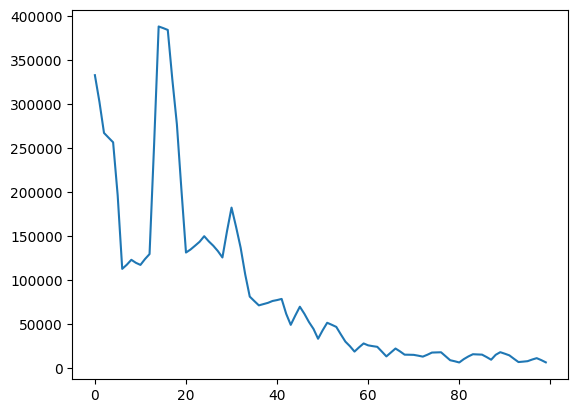

In [ ]:
df_imputed.iloc[2].plot()
df_normalized_full.iloc[2].plot()


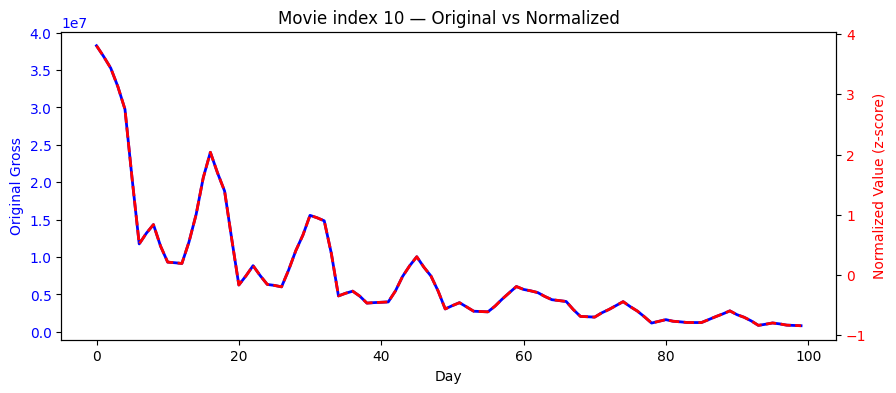

In [ ]:
i = 10

# Extract time series values only (columns '0' to '99')
original = df_imputed.iloc[i, :100].values
normalized = df_normalized_full.iloc[i, :100].values

# Create dual y-axis plot
fig, ax1 = plt.subplots(figsize=(10, 4))

# Left y-axis: original
ax1.plot(original, color="blue", label="Original", linewidth=2)
ax1.set_ylabel("Original Gross", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# Right y-axis: normalized
ax2 = ax1.twinx()
ax2.plot(normalized, color="red", linestyle="--", label="Normalized", linewidth=2)
ax2.set_ylabel("Normalized Value (z-score)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# Title and x-axis
plt.title(f"Movie index {i} — Original vs Normalized")
ax1.set_xlabel("Day")
plt.show()


# DETRENDING

In [96]:
from sktime.transformations.series.detrend import Detrender

In [ ]:
# Create the detrending transformer
detrender = Detrender()

# Apply row-wise to your dataset
detrended_all = []

for i in range(len(df_normalized_full)):
    y = pd.Series(df_normalized_full.iloc[i, :100].values)
    detrended_y = detrender.fit_transform(y)
    detrended_all.append(detrended_y.to_numpy())


In [98]:
df_detrended = pd.DataFrame(detrended_all, columns=df_normalized_full.columns[:100])
df_detrended_full = pd.concat([df_detrended, df_normalized_full.iloc[:, 100:]], axis=1)

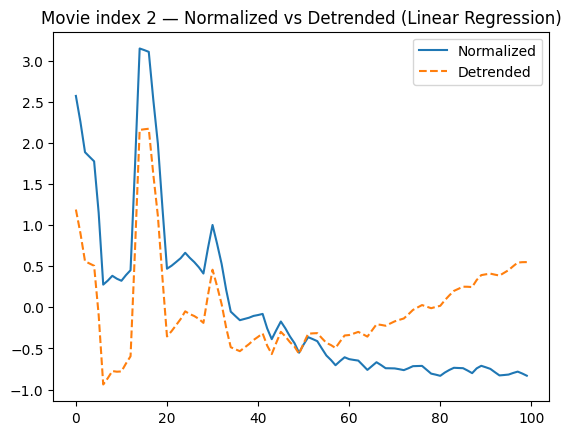

In [ ]:
i = 2
plt.plot(df_normalized_full.iloc[i, :100].values, label="Normalized")
plt.plot(df_detrended_full.iloc[i, :100].values, label="Detrended", linestyle="--")
plt.title(f"Movie index {i} — Normalized vs Detrended (Linear Regression)")
plt.legend()
plt.show()


# APPROXIMATION

In [102]:
from pyts.approximation import PiecewiseAggregateApproximation

In [103]:
# Extract time series only (assumed to be detrended)
X = df_detrended_full.iloc[:, :100].values  # shape: (1134, 100)

# Define PAA transformer: reduce to 10 segments
paa = PiecewiseAggregateApproximation(window_size=None, output_size=10)

# Apply PAA
X_paa = paa.fit_transform(X)  # shape: (1134, 10)


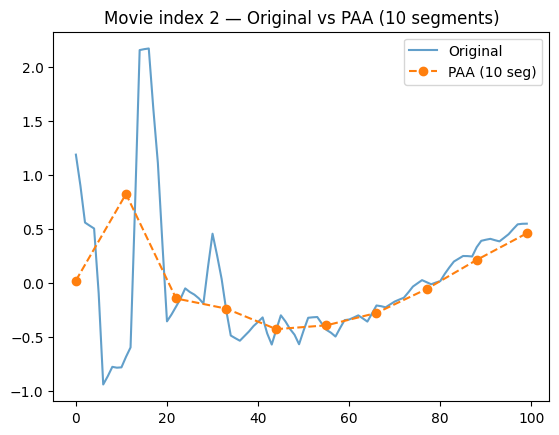

In [ ]:
i = 2  # any movie index

plt.plot(X[i], label="Original", alpha=0.7)
plt.plot(
    np.linspace(0, 99, 10), X_paa[i], label="PAA (10 seg)", marker="o", linestyle="--"
)
plt.title(f"Movie index {i} — Original vs PAA (10 segments)")
plt.legend()
plt.show()


In [105]:
np.save("arrays/X_paa", X_paa)


In [109]:
df_detrended_full.to_csv("dataset/time_series_post.csv")